In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
covertype = fetch_ucirepo(id=31) 
  
# data (as pandas dataframes) 
X = covertype.data.features 
y = covertype.data.targets 
  
# metadata 
print(covertype.metadata) 
  
# variable information 
print(covertype.variables) 

{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [3]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data splitting and cross validation
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score

# Decision tree model
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

In [4]:
# if y is a one-column DataFrame, convert it to a series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# basic shape checks
print("X shape:", X.shape)
print("y shape:", y.shape)

# first few rows
print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 rows of y:")
display(y.head())

# check class distribution
print("\nClass distribution:")
print(y.value_counts().sort_index())

# check for missing values
print("\nMissing values in X:")
print(X.isnull().sum().sum())

print("Missing values in y:")
print(y.isnull().sum())

X shape: (581012, 54)
y shape: (581012,)

First 5 rows of X:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,0



First 5 rows of y:


0    5
1    5
2    2
3    2
4    5
Name: Cover_Type, dtype: int64


Class distribution:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Missing values in X:
0
Missing values in y:
0


In [5]:
# the first split is 80% for train validation and 20% test 
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# second split is from the 80% make 12.5% to validation giving 70% train and 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

# check the sizes
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# make sure the percentages are correct
total = len(X)
print("\nTraining %:", len(X_train) / total)
print("Validation %:", len(X_val) / total)
print("Test %:", len(X_test) / total)

Training set shape: (406707, 54) (406707,)
Validation set shape: (58102, 54) (58102,)
Test set shape: (116203, 54) (116203,)

Training %: 0.6999975904112136
Validation %: 0.10000137690787798
Test %: 0.2000010326809085


In [6]:
# basic decision tree
baseline_tree = DecisionTreeClassifier(random_state=42)

# train the model
baseline_tree.fit(X_train, y_train)

# predictions
y_train_pred_base = baseline_tree.predict(X_train)
y_val_pred_base = baseline_tree.predict(X_val)

# accuracy
train_acc_base = accuracy_score(y_train, y_train_pred_base)
val_acc_base = accuracy_score(y_val, y_val_pred_base)

print("Baseline Training Accuracy:", train_acc_base)
print("Baseline Validation Accuracy:", val_acc_base)

Baseline Training Accuracy: 1.0
Baseline Validation Accuracy: 0.9362672541392724


In [7]:
# 5 fold stratified cross validation // more splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline model for CV
cv_tree = DecisionTreeClassifier(random_state=42)

# CV accuracy scores
cv_scores = cross_val_score(
    cv_tree,
    X_train,
    y_train,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

Cross-validation accuracy scores: [0.9275651  0.92638489 0.92769944 0.92715851 0.92781008]
Mean CV accuracy: 0.9273236032259525
Std CV accuracy: 0.0005185878559192461


In [8]:
# parameter grid for tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# grid search with stratified k-fold CV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# fit grid search on training set only
grid_search.fit(X_train, y_train)

# best model and best parameters
best_tree = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.9330402480320557


In [9]:
# predictions on training and validation sets
y_train_pred = best_tree.predict(X_train)
y_val_pred = best_tree.predict(X_val)

# accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print("Tuned Model Training Accuracy:", train_acc)
print("Tuned Model Validation Accuracy:", val_acc)
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))

Tuned Model Training Accuracy: 1.0
Tuned Model Validation Accuracy: 0.9392964097621425
Validation Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     21184
           2       0.95      0.95      0.95     28330
           3       0.93      0.94      0.93      3576
           4       0.82      0.81      0.82       275
           5       0.83      0.82      0.83       949
           6       0.88      0.88      0.88      1737
           7       0.96      0.94      0.95      2051

    accuracy                           0.94     58102
   macro avg       0.90      0.90      0.90     58102
weighted avg       0.94      0.94      0.94     58102



In [10]:
# predict on test set
y_test_pred = best_tree.predict(X_test)

# test accuracy
test_acc = accuracy_score(y_test, y_test_pred)

print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.9393130986291232


In [11]:
import time
import numpy as np

num_runs = 10
times = []

for _ in range(num_runs):
    start = time.time()
    best_tree.predict(X_test)
    end = time.time()
    times.append(end - start)

print("Average inference time (seconds):", np.mean(times))
print("Std of inference time:", np.std(times))
print("Average time per sample:", np.mean(times) / len(X_test))

Average inference time (seconds): 0.0461946964263916
Std of inference time: 0.007360078843131235
Average time per sample: 3.975344563082847e-07


Weighted Precision: 0.9392807718956717
Weighted Recall: 0.9393130986291232
Weighted F1-score: 0.9392949275732456

Test Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42368
           2       0.95      0.95      0.95     56661
           3       0.93      0.93      0.93      7151
           4       0.84      0.83      0.84       549
           5       0.84      0.83      0.84      1899
           6       0.89      0.88      0.88      3473
           7       0.95      0.94      0.95      4102

    accuracy                           0.94    116203
   macro avg       0.90      0.90      0.90    116203
weighted avg       0.94      0.94      0.94    116203



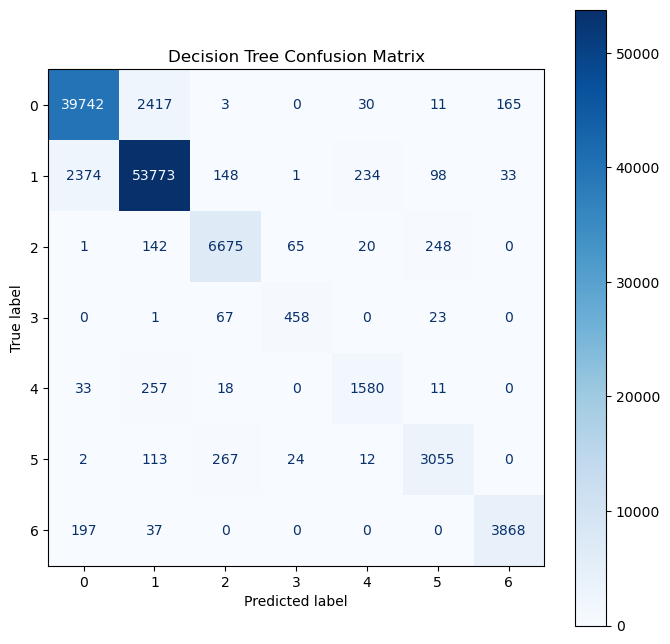

In [12]:
# precision, recall, f1 weighted
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average='weighted'
)

print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

#fFull classification report
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [13]:
print("     FINAL RESULTS     ")
print("Best Parameters:", grid_search.best_params_)
print("Mean CV Accuracy:", grid_search.best_score_)
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)
print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)

     FINAL RESULTS     
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mean CV Accuracy: 0.9330402480320557
Training Accuracy: 1.0
Validation Accuracy: 0.9392964097621425
Test Accuracy: 0.9393130986291232
Weighted Precision: 0.9392807718956717
Weighted Recall: 0.9393130986291232
Weighted F1-score: 0.9392949275732456


In [14]:
#................................
# EXTRA COMPARISON SECTION
# max_depth and min_samples_leaf
#................................

In [15]:
# store all results
combo_results = []

# different depths
for d in [10, 15, 20, 25, 30, None]:
    # different leaf sizes
    for leaf in [1, 2, 5, 10]:
        tree = DecisionTreeClassifier(
            criterion='entropy',
            max_depth=d,
            min_samples_leaf=leaf,
            min_samples_split=2,
            random_state=42
        )
        
        # train the model on the training set
        tree.fit(X_train, y_train)
        
        # predict on training and validation sets
        yhat_train = tree.predict(X_train)
        yhat_val = tree.predict(X_val)

        # compute accuracy
        tr_acc = accuracy_score(y_train, yhat_train)
        val_acc = accuracy_score(y_val, yhat_val)

        # store results as a tuple
        combo_results.append((d, leaf, tr_acc, val_acc))

        # Print results for each combination
        print(f"max_depth={d}, min_samples_leaf={leaf}: "
              f"train accuracy = {tr_acc:.6f}, validation accuracy = {val_acc:.6f}")

max_depth=10, min_samples_leaf=1: train accuracy = 0.777302, validation accuracy = 0.772779
max_depth=10, min_samples_leaf=2: train accuracy = 0.777255, validation accuracy = 0.772762
max_depth=10, min_samples_leaf=5: train accuracy = 0.777112, validation accuracy = 0.772693
max_depth=10, min_samples_leaf=10: train accuracy = 0.776667, validation accuracy = 0.772366
max_depth=15, min_samples_leaf=1: train accuracy = 0.873437, validation accuracy = 0.852415
max_depth=15, min_samples_leaf=2: train accuracy = 0.871915, validation accuracy = 0.851898
max_depth=15, min_samples_leaf=5: train accuracy = 0.868611, validation accuracy = 0.850315
max_depth=15, min_samples_leaf=10: train accuracy = 0.863531, validation accuracy = 0.847045
max_depth=20, min_samples_leaf=1: train accuracy = 0.945750, validation accuracy = 0.903532
max_depth=20, min_samples_leaf=2: train accuracy = 0.940960, validation accuracy = 0.902172
max_depth=20, min_samples_leaf=5: train accuracy = 0.931710, validation accura

In [16]:
# convert results into a pandas DataFrame for easier viewing
results_df = pd.DataFrame(
    combo_results,
    columns=["max_depth", "min_samples_leaf", "train_accuracy", "validation_accuracy"]
)

# sort by validation accuracy (highest first)
results_df = results_df.sort_values(by="validation_accuracy", ascending=False)

# show top 10 best combinations
results_df.head(10)

,max_depth,min_samples_leaf,train_accuracy,validation_accuracy
20,NaN,1,1.000000,0.939296
16,30.0,1,0.997003,0.938023
21,NaN,2,0.990927,0.937162
17,30.0,2,0.988333,0.936044
22,NaN,5,0.974291,0.930484
18,30.0,5,0.972390,0.929951
12,25.0,1,0.983735,0.928970
13,25.0,2,0.976243,0.926491
14,25.0,5,0.962327,0.920381
23,NaN,10,0.953465,0.918798


In [17]:
# select the best row (highest validation accuracy)
best_row = results_df.iloc[0]

print("Best combination based on validation accuracy:")
print(best_row)

Best combination based on validation accuracy:
max_depth                   NaN
min_samples_leaf       1.000000
train_accuracy         1.000000
validation_accuracy    0.939296
Name: 20, dtype: float64
